## This notebook is only about training three models:
- Bi-encoder
- Bi-encoder with fine-tuning
- Cross-encoder with fine-tuning

In [1]:
!pip install sentence_transformers accelerate datasets torch scikit-learn

In [2]:
from sentence_transformers import SentenceTransformer, InputExample, losses, CrossEncoder
import numpy as np
import random
import torch
from torch.utils.data import DataLoader

from datasets import Dataset

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report

/tmp/ipykernel_687/698087197.py:1: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses, CrossEncoder


In [3]:
SEED = 42

device = 'cpu'

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)

set_seed(SEED)


In [4]:
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
df = pd.read_csv("./data/train/rupaws_qqp_train.csv", sep=";")
df_ = pd.read_csv("./data/train/rupaws_wiki_train.csv", sep=';')

df = pd.concat([df, df_], ignore_index=True)
df = df.drop(columns=['Unnamed: 0'])

In [7]:
df.head()

,sentence1,sentence2,label
0,"Почему же такие богатые мусульманские страны, ...","Почему богатые мусульманские страны, такие как...",1
1,Что представляет собой государственно-частное ...,Что представляет собой государственно-частное ...,1
2,В чем различия между объектно-ориентированным ...,В чем различия между объектно-ориентированным ...,1
3,"Являются ли современные языки (т.е. латынь, др...","Являются ли древние языки (т.е. латынь, древне...",0
4,"Если вы можете любить кого-то, но не любить их...","Если вы можете любить кого-то, но не любить их...",1


In [8]:
embeddings_1 = model.encode(df['sentence1'].to_list(), device=device)
embeddings_2 = model.encode(df['sentence2'].to_list(), device=device)

In [9]:
print(embeddings_1.shape)
print(embeddings_2.shape)

(7596, 384)
(7596, 384)


In [10]:
embeddings_1 = embeddings_1 / np.linalg.norm(embeddings_1, axis=1, keepdims=True)
embeddings_2 = embeddings_2 / np.linalg.norm(embeddings_2, axis=1, keepdims=True)


In [11]:
print(embeddings_1.shape)
print(embeddings_2.shape)

(7596, 384)
(7596, 384)


In [12]:
cosine_sum = np.sum(embeddings_1 * embeddings_2, axis=1)

In [13]:
cosine_sum.min()

np.float32(0.42311805)

In [14]:
threshold = 0.5

y_pred = np.where(cosine_sum > threshold, 1, 0)

In [15]:
y_test = df['label']

In [16]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1-score: {f1_score(y_test, y_pred)}")

print(classification_report(y_test, y_pred))

Accuracy: 0.38915218536071616
F1-score: 0.5602729340409401
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4638
           1       0.39      1.00      0.56      2958

    accuracy                           0.39      7596
   macro avg       0.19      0.50      0.28      7596
weighted avg       0.15      0.39      0.22      7596



In [17]:
def threshold_choose(cosine_sum, y_test, steps, function_metric):
    best_choose = {"best": 0}

    thresholds = [1 / steps * i for i in range(steps + 1)]

    for threshold in thresholds:
        y_pred = np.where(cosine_sum > threshold, 1, 0)

        if function_metric(y_test, y_pred) > best_choose['best']:
            best_choose['best'] = function_metric(y_test, y_pred)
            best_choose['threshold'] = threshold
            best_choose['f1'] = f1_score(y_test, y_pred)
            best_choose['accuracy'] = accuracy_score(y_test, y_pred)
            best_choose['report'] = classification_report(y_test, y_pred)

    return best_choose

In [18]:
best = threshold_choose(cosine_sum, y_test, 25, f1_score)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
print('f1: ', best['f1'])
print('accuracy: ', best['accuracy'])
print(best['report'])
print('threshold', best['threshold'])

f1:  0.5779875015941844
accuracy:  0.5643759873617693
              precision    recall  f1-score   support

           0       0.74      0.44      0.55      4638
           1       0.46      0.77      0.58      2958

    accuracy                           0.56      7596
   macro avg       0.60      0.60      0.56      7596
weighted avg       0.64      0.56      0.56      7596

threshold 0.96


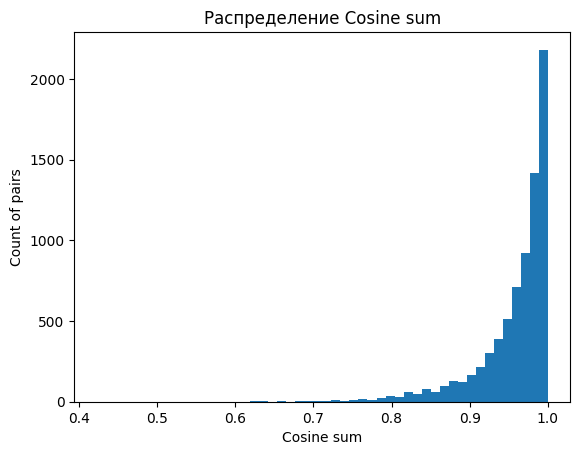

In [20]:
plt.hist(cosine_sum, bins=50)
plt.title("Распределение Cosine sum")
plt.xlabel("Cosine sum")
plt.ylabel("Count of pairs")
plt.grid(False)
plt.savefig('./artifacts/distribution_cosine_sum_exp01.png')
plt.show()

## This model is not suit for this task

We can see that distribution of cosine sum betwen 0.85 and 1, so this method is not good here

# Experiment 02 - Fine-tuning Bi-encoder

In [21]:
train_examples = [
    InputExample(texts=[row['sentence1'], row['sentence2']], label=float(row['label']))
    for _, row in df.iterrows()
]

In [22]:
train_loss = losses.CosineSimilarityLoss(model)

In [23]:
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

In [24]:
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,
    warmup_steps=100,
    output_path='./artifacts/bi_encoder_finetuned'
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.274674
1000,0.174026


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
df_test = pd.read_csv("./data/test/rupaws_qqp_and_wiki_test.csv", sep=';')

In [26]:
df_test = df_test.drop(columns=['Unnamed: 0'])

In [27]:
enbs1 = model.encode(df_test['sentence1'].to_list(), device=device)
enbs2 = model.encode(df_test['sentence2'].to_list(), device=device)

enbs1 = enbs1 / np.linalg.norm(enbs1, axis=1, keepdims=True)
enbs2 = enbs2 / np.linalg.norm(enbs2, axis=1, keepdims=True)

cosine_sum = np.sum(enbs1 * enbs2, axis=1)

In [28]:
y_test = df_test['label']
expe_2 = threshold_choose(cosine_sum, y_test, 10, f1_score)

print('f1: ', expe_2['f1'])
print('accuracy: ', expe_2['accuracy'])
print(expe_2['report'])
print('threshold', expe_2['threshold'])

f1:  0.6487163431433939
accuracy:  0.6646742378959952
              precision    recall  f1-score   support

           0       0.82      0.58      0.68      1024
           1       0.55      0.80      0.65       649

    accuracy                           0.66      1673
   macro avg       0.68      0.69      0.66      1673
weighted avg       0.71      0.66      0.67      1673

threshold 0.5


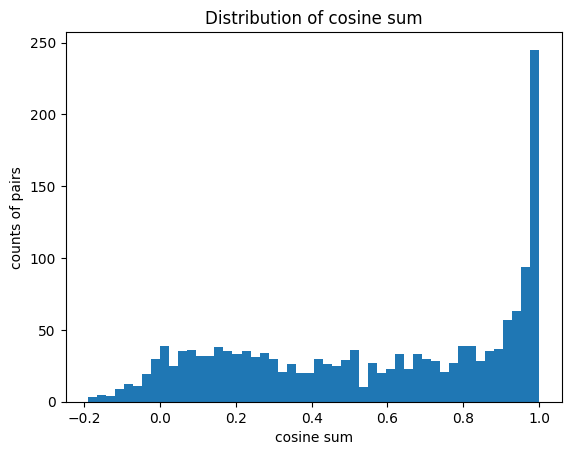

In [29]:
plt.hist(cosine_sum, bins=50)
plt.title("Distribution of cosine sum")
plt.xlabel("cosine sum")
plt.ylabel("counts of pairs")
plt.grid(False)
plt.savefig('./artifacts/distribution_cosine_sum_exp02.png')
plt.show()

## Bi-encoder with fine tuning

This experiment shows us better results than was without fine-tuning, so fine-tuning make model better
distribution was being better and more uniform

# Experiment with Cross-Encoder fine-tuning

In [30]:
cross_model = CrossEncoder('DiTy/cross-encoder-russian-msmarco')

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [31]:
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=8)
cross_model.fit(
    train_dataloader=train_dataloader,
    epochs=2,
    warmup_steps=50,
    output_path="./artifacts/cross_encoder_finetuned",
)

Step,Training Loss
500,0.691062
1000,0.512703
1500,0.381332


In [34]:
test_data = [[row['sentence1'], row['sentence2']] for _, row in df_test.iterrows()]

y_pred = cross_model.predict(test_data)

In [35]:
cross_encoder_d = threshold_choose(y_pred, df_test['label'], 20, f1_score)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
print(f'f1_score: {cross_encoder_d['f1']}')
print(f'accuracy: {cross_encoder_d['accuracy']}')
print(f'threshold: {cross_encoder_d['threshold']}')
print(f'{cross_encoder_d['report']}')

f1_score: 0.7058823529411765
accuracy: 0.7698744769874477
threshold: 0.4
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1024
           1       0.70      0.71      0.71       649

    accuracy                           0.77      1673
   macro avg       0.76      0.76      0.76      1673
weighted avg       0.77      0.77      0.77      1673



In [41]:
!zip artifacts.zip artifacts

updating: artifacts/ (stored 0%)


In [40]:
cross_model.save_pretrained('./artifacts/cross_encoder_finetuned')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]